# Capacity of neural network

Will train a neural network to classify whether a given latitude/longitude is inside India using the boundaries dataset. The goal is to understand the capacity of neural networks so will use the entire dataset for training and plotting to see if it works fine. 

In [1]:
import torch
import torch.nn as nn
import pandas as pd
from ipywidgets import IntProgress, Label
from IPython.display import display

## Feedforward neural network

Model is a simple feedforward neural network of n layers and m units per hidden layer. Will use sigmoid on the output layer and RELU on hidden layers for better gradient flow.


In [2]:
def model(layers=8, units=16):
    layers_list = []
    layers_list.append(nn.Linear(2, units))
    layers_list.append(nn.ReLU())
    for _ in range(layers - 2):
        layers_list.append(nn.Linear(units, units))
        layers_list.append(nn.ReLU())
    layers_list.append(nn.Linear(units, 1))
    layers_list.append(nn.Sigmoid())
    return nn.Sequential(*layers_list)

In [3]:
dataset = pd.read_csv('../data/india-boundaries.csv').sample(frac=1).reset_index(drop=True)
x = torch.tensor(dataset[['lat', 'lon']].values, dtype=torch.float32)
y = torch.tensor(dataset[['contains']].values, dtype=torch.float32)

## Mini batch gradient descent

Shuffled the dataset above. Will split the dataset into fixed sized batches and do mini batch gradient descent. The loss function is binary cross entropy which is matches the problem perfectly. We set the learning rate to 0.01 by default.


In [4]:
def train(model, lr=0.01, epochs=100, batch_size=1024):
    optimizer = torch.optim.Adagrad(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    progress = IntProgress(min=0, max=epochs)
    label = Label()
    display(progress, label)

    for epoch in range(epochs):
        total_loss = 0
        for i in range(batch_size, len(x), batch_size):
            start = i - batch_size
            end = i
            x_batch = x[start:end]
            y_batch = y[start:end]
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item() * (end - start)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        label.value = f'Epoch {epoch}, Loss: {total_loss/len(x):.4f}'
        progress.value = epoch

In [5]:
import matplotlib.pyplot as plt

def visualize(model):
    predicted = model(x).detach().numpy()
    plt.figure(figsize=(8, 10))
    scatter = plt.scatter(
        dataset['lon'], 
        dataset['lat'], 
        c=predicted,
        s=10,
        cmap='magma',
    )
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Points Inside India Boundaries')
    plt.show()

## 8 Layers and 32 Neurons per layer (192 hidden + 64 input + 32 output parameters = 288 parameters, without bias)

The loss comes out to around 0.08

In [6]:
m = model(layers=8, units=32)
train(m, lr=0.03, epochs=500)

IntProgress(value=0, max=500)

Label(value='')

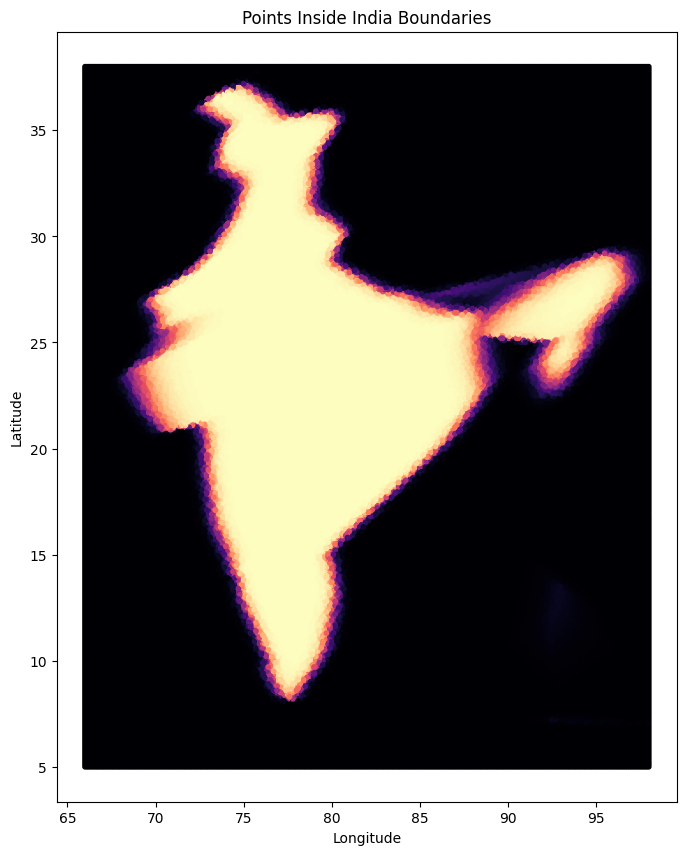

In [7]:
visualize(m)

## 6 Layers and 64 Neurons per layer (256 hidden + 128 input + 64 output parameters = 448 parameters, without bias)

Reduced the depth, but increased the number of neurons per layer. Eventhough the parameters have almost doubled, the loss is marginally worse here. 

Depth has better expressibility, but might have to train longer as the gradient flow deeper might result in vanishing gradients.


In [9]:
m = model(layers=6, units=64)
train(m, lr=0.03, epochs=500)

IntProgress(value=0, max=500)

Label(value='')

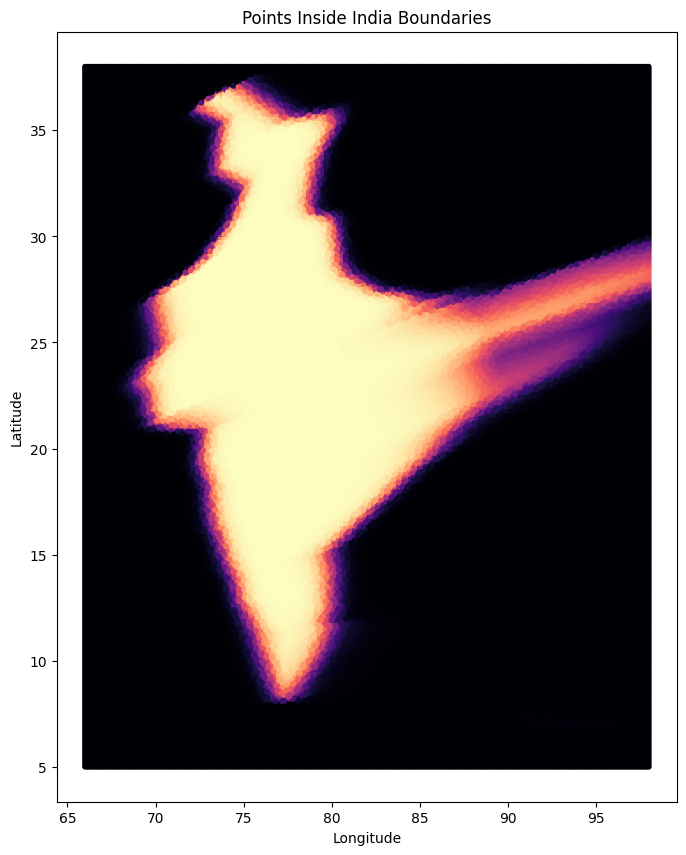

In [10]:
visualize(m)